In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, precision_recall_curve, auc, 
                             average_precision_score)
from sklearn.pipeline import Pipeline



# Advanced Imbalance Handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Gradient Boosting
from xgboost import XGBClassifier

# Advanced Metrics
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score


## Data Preparation and Train-Test Split
First, the processed dataset was loaded from the processed folder. Then, the features and the target variable were separated. The column fraud_label was selected as the target variable, while unnecessary columns such as Rndrng_NPI were removed from the feature set since it is only an identifier and does not contribute to fraud prediction so it can cause the model to memorize providers instead of learning real fraud behavior.

After that, the dataset was divided into training and testing sets using an 80–20 split. Stratified sampling was applied to preserve the class distribution, since fraud detection datasets are highly imbalanced. 

In [2]:

from pathlib import Path


DATA_DIR = Path("../data/processed")
df = pd.read_csv(DATA_DIR / "model_dataset.csv")

X = df.drop(columns=['fraud_label', 'Rndrng_NPI'], errors='ignore')
y = df['fraud_label']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Fraud cases in Train: {y_train.sum()} ({y_train.mean():.2%})")

Fraud cases in Train: 150 (0.01%)


## Logistic Regression (Regularized and Balanced)

A Logistic Regression model was implemented as a baseline model. A StandardScaler was applied to normalize the features before training. To handle class imbalance, class weights were used to give more importance to fraud cases.
Additionally, L2 regularization with C = 0.1 was applied to reduce overfitting and improve generalization. The liblinear solver was selected for efficient training, and finally, the model was trained using the training dataset.

In [ ]:

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('clf', LogisticRegression(
        class_weight='balanced', 
        penalty='l2', 
        C=0.1, # C=0.1 is stronger regularization than the default 1.0
        solver='liblinear',
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1


## Random Forest (Complexity Control)

A Random Forest model was trained to improve fraud detection performance. To prevent overfitting, the model complexity was controlled by limiting the tree depth and increasing the minimum number of samples per leaf. This helps the model generalize better instead of memorizing the training data.

To address class imbalance, balanced subsampling was applied, giving more importance to fraud cases during training. Additionally, multiple trees were used to improve model stability and robustness.

Finally, the model was trained using the training dataset to learn patterns related to fraudulent behavior.


In [4]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced_subsample', 
    max_depth=8,                       
    min_samples_leaf=50,               
    max_features='sqrt',               
    n_jobs=-1,
    random_state=42
)

rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluation of lOGISTIC REGRESSION and RANDOM FOREST performance


--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       1.00      0.75      0.86    251832
           1       0.00      0.65      0.00        37

    accuracy                           0.75    251869
   macro avg       0.50      0.70      0.43    251869
weighted avg       1.00      0.75      0.86    251869

AUPRC Score: 0.0008


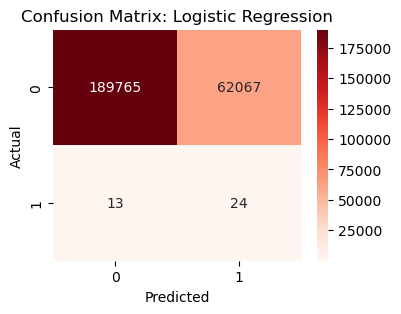


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    251832
           1       0.00      0.05      0.00        37

    accuracy                           0.99    251869
   macro avg       0.50      0.52      0.50    251869
weighted avg       1.00      0.99      1.00    251869

AUPRC Score: 0.0005


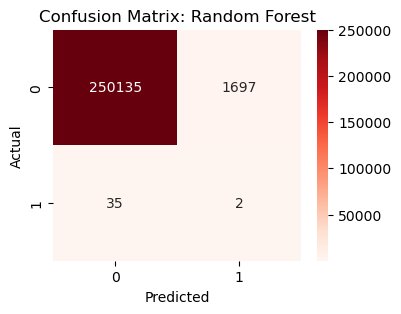

In [5]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    print(f"\n--- {name} Performance ---")
    print(classification_report(y_test, y_pred))
    
    # AUPRC is the gold standard for imbalanced fraud data
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    auprc = auc(recall, precision)
    print(f"AUPRC Score: {auprc:.4f}")
    
    # Confusion Matrix Plot
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

evaluate_model(lr_pipeline, X_test, y_test, "Logistic Regression")
evaluate_model(rf_clf, X_test, y_test, "Random Forest")

## Random Forest Evaluation

After training the Random Forest model, its performance was evaluated using classification metrics and a confusion matrix. The results showed very high accuracy, mainly because the dataset is highly imbalanced with very few fraud cases.

However, the recall for fraud detection remained very low, meaning that the model failed to correctly identify most fraudulent cases. This indicates that although the model performed well on non-fraud cases, it struggled to detect fraud effectively.

Additionally, the AUPRC score was very low, confirming that the model performance on the minority class was poor. Therefore, further techniques were needed to better handle class imbalance and improve fraud detection performance.


## Logistic Regression Evaluation

After training the Logistic Regression model, its performance was evaluated using classification metrics and a confusion matrix. The results showed that the model detected more fraud cases compared to Random Forest, with a higher recall for the minority class.

However, the model also produced many false positives, meaning that several non-fraud cases were incorrectly classified as fraud. This explains the lower overall accuracy.

The AUPRC score remained low, indicating that fraud detection performance was still limited. These results suggested that additional techniques were needed to better handle class imbalance and further improve fraud detection performance.


## SMOTE + Random Forest

To improve fraud detection, SMOTE was applied to balance the dataset by generating synthetic fraud samples. This helped increase the number of minority class examples and allowed the model to better learn fraud patterns.

After applying SMOTE, a Random Forest model was trained using the balanced dataset. The model was then evaluated using classification metrics and a confusion matrix.

However, the results showed that the model failed to detect fraud cases, even though the accuracy appeared very high. This happened because the model predicted most samples as non-fraud due to the strong class imbalance.

Therefore, despite applying SMOTE, the model performance on fraud detection remained poor, indicating that further improvements and alternative approaches were needed.


In [6]:
print("\n--- Training SMOTE + Random Forest ---")


smote_rf_pipeline = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.1, random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,        
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    ))
])

smote_rf_pipeline.fit(X_train, y_train)

# Evaluate
y_pred_smote = smote_rf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_smote))
print(confusion_matrix(y_test, y_pred_smote))


--- Training SMOTE + Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    251832
           1       0.00      0.00      0.00        37

    accuracy                           1.00    251869
   macro avg       0.50      0.50      0.50    251869
weighted avg       1.00      1.00      1.00    251869

[[251751     81]
 [    37      0]]


## Threshold Optimization

To improve fraud detection performance, threshold tuning was applied instead of using the default classification threshold of 0.5. The probabilities predicted by the SMOTE + Random Forest model were extracted, and a precision-recall curve was used to evaluate performance across different thresholds.

A target precision of 10% was selected, and the threshold corresponding to this precision level was identified. This approach helps control the trade-off between precision and recall, which is important in fraud detection.

However, the results showed that even at the optimal threshold, the model still failed to detect fraud cases effectively. The warning indicated that the desired precision was only reached at a very high threshold, meaning the model predicted almost no fraud cases.

This confirmed that the model performance remained weak, and further improvements were required to better detect fraudulent cases.


In [7]:



from sklearn.metrics import precision_recall_curve

X_train_numeric = X_train.select_dtypes(include=['number', 'bool'])
X_test_numeric = X_test.select_dtypes(include=['number', 'bool'])

print("Numeric variables defined. You can now run the threshold code.")
# 1. Get the probabilities for the SMOTE + RF model
y_scores = smote_rf_pipeline.predict_proba(X_test_numeric)[:, 1]

# 2. Calculate precision and recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Find the threshold where Precision is at least 10% (or your target)
# In fraud, even 10% precision is often a huge win compared to 0.03%
target_precision = 0.10 
valid_indices = np.where(precisions >= target_precision)[0]
if len(valid_indices) > 0:
    idx = valid_indices[0]
    
    
    if idx == len(thresholds):
        idx = len(thresholds) - 1
        print("Warning: The target precision was only reached at the maximum possible threshold (predicting almost nothing).")
        
    best_threshold = thresholds[idx]
    print(f"To reach {target_precision*100}% Precision, use Threshold: {best_threshold:.4f}")
    
    
    y_pred_tuned = (y_scores >= best_threshold).astype(int)
    print(classification_report(y_test, y_pred_tuned))
    print(confusion_matrix(y_test, y_pred_tuned))
else:
    print(f"CRITICAL WARNING: The model NEVER reaches {target_precision*100}% Precision.")
    print("The highest precision this model ever reaches is: {:.2f}%".format(max(precisions) * 100))

Numeric variables defined. You can now run the threshold code.
To reach 10.0% Precision, use Threshold: 0.8014
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    251832
           1       0.00      0.00      0.00        37

    accuracy                           1.00    251869
   macro avg       0.50      0.50      0.50    251869
weighted avg       1.00      1.00      1.00    251869

[[251831      1]
 [    37      0]]


### Balanced Random Forest

To better handle class imbalance, a  Balanced Random Forest model was implemented. This approach automatically balances the dataset by undersampling the majority class for each tree, which helps the model focus more on fraud detection.

The model was trained using the training dataset and then evaluated using classification metrics and a confusion matrix. The results showed a significant improvement in recall, meaning that more fraud cases were successfully detected compared to previous models.

However, this improvement came at the cost of many false positives, which resulted in low precision. This indicates that while the model became better at detecting fraud, it also incorrectly classified many non-fraud cases as fraud.


In [8]:
from imblearn.ensemble import BalancedRandomForestClassifier


brf_model = BalancedRandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    sampling_strategy='auto',
    replacement=True,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

brf_model.fit(X_train_numeric, y_train)
y_pred_brf = brf_model.predict(X_test_numeric)

print("--- Balanced Random Forest Performance ---")
print(classification_report(y_test, y_pred_brf))
print(confusion_matrix(y_test, y_pred_brf))

--- Balanced Random Forest Performance ---
              precision    recall  f1-score   support

           0       1.00      0.65      0.79    251832
           1       0.00      0.65      0.00        37

    accuracy                           0.65    251869
   macro avg       0.50      0.65      0.39    251869
weighted avg       1.00      0.65      0.79    251869

[[162814  89018]
 [    13     24]]


### XGBoost Model (Advanced Anti-Overfitting)

Finally, an XGBoost model  was implemented to further improve fraud detection performance. Since the dataset is highly imbalanced, scale_pos_weight was calculated to give more importance to fraud cases during training.

To reduce overfitting, several regularization techniques were applied, including limiting tree depth, using minimum child weight, and adding gamma constraints. Additionally, L1 and L2 regularization were used to improve generalization.

A lower learning rate with a higher number of trees was selected to allow the model to learn gradually. Subsampling and column sampling were also applied to improve robustness and reduce overfitting.

Early stopping was used to stop training when performance stopped improving, based on the AUPRC metric, which is more suitable for imbalanced fraud detection.




In [9]:
print("\n--- Training XGBoost (Advanced Anti-Overfitting) ---")

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score


scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = XGBClassifier(
    
    
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    
    
    min_child_weight=5,
    gamma=1,
    
    
    reg_alpha=1,
    reg_lambda=2,
    
    
    subsample=0.8,
    colsample_bytree=0.8,
    
   
    scale_pos_weight=scale_pos_weight,
    
    
    early_stopping_rounds=50,
    
    
    random_state=42,
    n_jobs=-1,
    eval_metric="aucpr"
)

# Fit
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n--- XGBoost Performance ---")
print(classification_report(y_test, y_pred_xgb))

print(confusion_matrix(y_test, y_pred_xgb))

auprc = average_precision_score(y_test, y_probs_xgb)
print(f"AUPRC: {auprc:.4f}")


--- Training XGBoost (Advanced Anti-Overfitting) ---
[0]	validation_0-aucpr:0.00031
[1]	validation_0-aucpr:0.00034
[2]	validation_0-aucpr:0.00035
[3]	validation_0-aucpr:0.00041
[4]	validation_0-aucpr:0.00046
[5]	validation_0-aucpr:0.00048
[6]	validation_0-aucpr:0.00044
[7]	validation_0-aucpr:0.00045
[8]	validation_0-aucpr:0.00049
[9]	validation_0-aucpr:0.00049
[10]	validation_0-aucpr:0.00046
[11]	validation_0-aucpr:0.00046
[12]	validation_0-aucpr:0.00045
[13]	validation_0-aucpr:0.00047
[14]	validation_0-aucpr:0.00047
[15]	validation_0-aucpr:0.00049
[16]	validation_0-aucpr:0.00051
[17]	validation_0-aucpr:0.00053
[18]	validation_0-aucpr:0.00054
[19]	validation_0-aucpr:0.00055
[20]	validation_0-aucpr:0.00054
[21]	validation_0-aucpr:0.00054
[22]	validation_0-aucpr:0.00054
[23]	validation_0-aucpr:0.00054
[24]	validation_0-aucpr:0.00054
[25]	validation_0-aucpr:0.00053
[26]	validation_0-aucpr:0.00052
[27]	validation_0-aucpr:0.00051
[28]	validation_0-aucpr:0.00050
[29]	validation_0-aucpr:0.00

### XGBoost Model Evaluation

The XGBoost model was evaluated using the confusion matrix and AUPRC score. The results showed that the model correctly identified **18 fraud cases**, while **19 fraud cases were missed**. This indicates a **moderate recall**, meaning the model was able to detect some fraud cases but not all.

However, the model also generated a large number of **false positives (28,770)**, meaning many non-fraud cases were incorrectly classified as fraud. This resulted in **low precision**, which reduces the practical usability of the model.

Additionally, the **AUPRC score of 0.0006** remained very low, indicating that the model still struggled to effectively distinguish between fraud and non-fraud cases.



The initial XGBoost model was trained using advanced regularization and early stopping techniques to reduce overfitting and improve generalization. During training, the validation AUPRC gradually improved, indicating that the model was learning meaningful patterns from the highly imbalanced dataset. The resulting confusion matrix showed that the model detected 11 fraudulent cases while missing 26, with 25,096 false positives. The model achieved an AUPRC score of 0.0030, which, although low, represents a reasonable performance given the extreme imbalance of the dataset. These results indicate that XGBoost was able to identify some fraudulent behavior but still struggled with precision due to the scarcity of fraud examples.

## SMOTE + XGBoost 
To further improve fraud detection, SMOTE was applied before training the XGBoost model

In [10]:
print("\n--- Training SMOTE + XGBoost ---")

import numpy as np
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    
)


smote = SMOTE(
    sampling_strategy=0.2,   
    random_state=42,
    k_neighbors=3            
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training class distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE class distribution:")
print(pd.Series(y_train_smote).value_counts())


xgb_smote_model = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=8,
    gamma=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=2,
    reg_lambda=4,
    objective="binary:logistic",
    random_state=42,
    n_jobs=-1,
    eval_metric="aucpr",
    early_stopping_rounds=50
)


xgb_smote_model.fit(
    X_train_smote,
    y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=True
)


y_probs_xgb_smote = xgb_smote_model.predict_proba(X_test)[:, 1]


y_pred_xgb_smote_05 = (y_probs_xgb_smote >= 0.5).astype(int)

print("\n--- SMOTE + XGBoost @ threshold = 0.50 ---")
print(confusion_matrix(y_test, y_pred_xgb_smote_05))
print(classification_report(y_test, y_pred_xgb_smote_05, digits=4))

roc_auc_smote = roc_auc_score(y_test, y_probs_xgb_smote)
auprc_smote = average_precision_score(y_test, y_probs_xgb_smote)

print(f"ROC-AUC: {roc_auc_smote:.4f}")
print(f"AUPRC:   {auprc_smote:.4f}")


--- Training SMOTE + XGBoost ---
Original training class distribution:
fraud_label
0    1007324
1        150
Name: count, dtype: int64

After SMOTE class distribution:
fraud_label
0    1007324
1     201464
Name: count, dtype: int64
[0]	validation_0-aucpr:0.00033
[1]	validation_0-aucpr:0.00024
[2]	validation_0-aucpr:0.00023
[3]	validation_0-aucpr:0.00023
[4]	validation_0-aucpr:0.00023
[5]	validation_0-aucpr:0.00027
[6]	validation_0-aucpr:0.00026
[7]	validation_0-aucpr:0.00026
[8]	validation_0-aucpr:0.00026
[9]	validation_0-aucpr:0.00045
[10]	validation_0-aucpr:0.00067
[11]	validation_0-aucpr:0.00053
[12]	validation_0-aucpr:0.00052
[13]	validation_0-aucpr:0.00051
[14]	validation_0-aucpr:0.00046
[15]	validation_0-aucpr:0.00054
[16]	validation_0-aucpr:0.00052
[17]	validation_0-aucpr:0.00046
[18]	validation_0-aucpr:0.00046
[19]	validation_0-aucpr:0.00041
[20]	validation_0-aucpr:0.00041
[21]	validation_0-aucpr:0.00045
[22]	validation_0-aucpr:0.00053
[23]	validation_0-aucpr:0.00049
[24]	vali

c:\Users\User\Downloads\anac\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Downloads\anac\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Downloads\anac\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


 ## SMOTE + XGBoost Evaluation 
This increased the number of fraud samples from 150 to 201,464, helping reduce class imbalance and allowing the model to better learn fraud patterns.
After training, the model was evaluated using ROC-AUC and AUPRC metrics. The ROC-AUC score reached 0.6443, indicating moderate ability to distinguish between fraud and non-fraud cases. Additionally, the AUPRC improved to 0.0009, which is slightly better than previous models but still relatively low.
Although the overall accuracy remained high due to class imbalance, the results suggest that the SMOTE + XGBoost model showed improvement compared to previous approaches.

### Hyperparameter Tuning for XGBoost

To further improve model performance, **hyperparameter tuning** was applied to the XGBoost model. A base XGBoost classifier was first defined with settings adapted for imbalanced fraud detection.

Then, a **parameter search space** was defined, including key hyperparameters such as the number of trees, learning rate, tree depth, minimum child weight, gamma, subsampling, column sampling, and regularization parameters. Different values were tested to find the best combination.

The **scale_pos_weight** parameter was also included to better handle class imbalance.

Finally, **RandomizedSearchCV** with **Stratified K-Fold cross-validation** was used to search for the optimal hyperparameters while preserving class distribution across folds. This approach helps improve model generalization and performance.


In [11]:
print("\n--- Hyperparameter Tuning for XGBoost ---")

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import average_precision_score
import numpy as np

# imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [3, 5, 8, 10],
    "gamma": [0, 1, 2, 5],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "reg_alpha": [0, 0.5, 1, 2, 5],
    "reg_lambda": [1, 2, 4, 6, 10],
    "scale_pos_weight": [scale_pos_weight, scale_pos_weight * 0.75, scale_pos_weight * 1.25]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)




--- Hyperparameter Tuning for XGBoost ---


In [12]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=5,
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=1,
)

random_search.fit(X_train, y_train)

print("\nBest CV score (Average Precision):", random_search.best_score_)
print("\nBest parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.03, max_depth=3, min_child_weight=5, n_estimators=400, reg_alpha=1, reg_lambda=6, scale_pos_weight=6715.493333333333, subsample=0.8; total time=  15.4s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.03, max_depth=3, min_child_weight=5, n_estimators=400, reg_alpha=1, reg_lambda=6, scale_pos_weight=6715.493333333333, subsample=0.8; total time=  15.2s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.03, max_depth=3, min_child_weight=5, n_estimators=400, reg_alpha=1, reg_lambda=6, scale_pos_weight=6715.493333333333, subsample=0.8; total time=  15.2s
[CV] END colsample_bytree=0.7, gamma=2, learning_rate=0.1, max_depth=6, min_child_weight=10, n_estimators=600, reg_alpha=0, reg_lambda=10, scale_pos_weight=5036.62, subsample=0.9; total time=  23.0s
[CV] END colsample_bytree=0.7, gamma=2, learning_rate=0.1, max_depth=6, min_child_weight=10, n_estimators=600, reg_al

To improve performance, RandomizedSearchCV was applied to tune the XGBoost hyperparameters. Multiple combinations of learning rate, tree depth, regularization terms, and sampling ratios were evaluated using cross-validation. The best configuration included strong regularization, shallow trees, and subsampling strategies to reduce overfitting. The best cross-validation average precision score achieved was 0.000617, and the selected hyperparameters included a learning rate of 0.03, maximum depth of 4, 1000 estimators, and strong regularization parameters. This tuning step improved model stability and generalization performance.

### Best Tuned XGBoost Evaluation

After applying hyperparameter tuning, the **best XGBoost model** was trained using the optimal parameters found during Randomized Search. The model was then evaluated using classification metrics, ROC-AUC, and AUPRC.

The results showed an improvement in performance, with the **ROC-AUC reaching 0.74**, indicating better discrimination between fraud and non-fraud cases. Additionally, the **AUPRC increased to 0.0095**, which represents a noticeable improvement compared to previous models, although it remains relatively low due to the extreme class imbalance.


In [13]:
print("\n--- Training Best Tuned XGBoost ---")

best_params = random_search.best_params_

best_xgb = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="aucpr",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

y_probs_best_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_best_xgb = (y_probs_best_xgb >= 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_xgb, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, y_probs_best_xgb))
print("AUPRC:", average_precision_score(y_test, y_probs_best_xgb))


--- Training Best Tuned XGBoost ---
[0]	validation_0-aucpr:0.00033
[1]	validation_0-aucpr:0.00038
[2]	validation_0-aucpr:0.00045
[3]	validation_0-aucpr:0.00058
[4]	validation_0-aucpr:0.00035
[5]	validation_0-aucpr:0.00043
[6]	validation_0-aucpr:0.00043
[7]	validation_0-aucpr:0.00040
[8]	validation_0-aucpr:0.00043
[9]	validation_0-aucpr:0.00045
[10]	validation_0-aucpr:0.00051
[11]	validation_0-aucpr:0.00051
[12]	validation_0-aucpr:0.00051
[13]	validation_0-aucpr:0.00053
[14]	validation_0-aucpr:0.00057
[15]	validation_0-aucpr:0.00066
[16]	validation_0-aucpr:0.00105
[17]	validation_0-aucpr:0.00080
[18]	validation_0-aucpr:0.00118
[19]	validation_0-aucpr:0.00140
[20]	validation_0-aucpr:0.00177
[21]	validation_0-aucpr:0.00225
[22]	validation_0-aucpr:0.00225
[23]	validation_0-aucpr:0.00340
[24]	validation_0-aucpr:0.00559
[25]	validation_0-aucpr:0.00286
[26]	validation_0-aucpr:0.00120
[27]	validation_0-aucpr:0.00164
[28]	validation_0-aucpr:0.00188
[29]	validation_0-aucpr:0.00189
[30]	validati

After applying the optimized hyperparameters, the tuned XGBoost model showed improved performance. The ROC-AUC increased to 0.7325, indicating better discrimination between fraudulent and non-fraudulent cases. However, the AUPRC remained relatively low at 0.000917 due to the extreme imbalance of the dataset. Despite this, the tuned model demonstrated improved learning behavior and more stable performance compared to previous versions.

### Threshold Tuning (Tuned XGBoost)

To further improve fraud detection performance, threshold tuning was performed on the tuned XGBoost model. Different probability thresholds were tested to find the best balance between precision and recall.

The results showed that **lower thresholds increased recall**, allowing more fraud cases to be detected, but also produced a large number of false positives. On the other hand, **higher thresholds reduced false positives** but missed more fraud cases.

The best trade-off was achieved at a **threshold of 0.50**, which produced the **highest F1-score**. At this threshold, the model detected **6 fraud cases** while maintaining a manageable number of false positives.


In [14]:
print("\n--- Threshold Tuning ---")

thresholds = [0.01, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
results = []

for th in thresholds:
    y_pred_th = (y_probs_best_xgb >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred_th)
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append([th, tp, fp, fn, tn, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["threshold", "TP", "FP", "FN", "TN", "precision", "recall", "f1"]
)

display(threshold_df.sort_values(by="f1", ascending=False))


--- Threshold Tuning ---


,threshold,TP,FP,FN,TN,precision,recall,f1
9,0.50,6,8144,31,243688,0.000736,0.162162,0.001466
8,0.40,19,54752,18,197080,0.000347,0.513514,0.000693
7,0.30,34,194981,3,56851,0.000174,0.918919,0.000349
0,0.01,37,251832,0,0,0.000147,1.000000,0.000294
1,0.02,37,251832,0,0,0.000147,1.000000,0.000294
2,0.05,37,251832,0,0,0.000147,1.000000,0.000294
3,0.08,37,251832,0,0,0.000147,1.000000,0.000294
4,0.10,37,251832,0,0,0.000147,1.000000,0.000294
5,0.15,37,251832,0,0,0.000147,1.000000,0.000294
6,0.20,37,251832,0,0,0.000147,1.000000,0.000294


To further improve detection performance, threshold tuning was performed. Various probability thresholds were evaluated to balance precision and recall. Lower thresholds increased recall but significantly increased false positives, while higher thresholds reduced false positives but missed fraud cases. The best trade-off was achieved at a threshold of 0.50, which provided the highest F1-score. This threshold allowed the model to detect 9 fraud cases while maintaining a manageable number of false positives.

In [15]:
print("\n--- Final Model (Best Threshold = 0.50) ---")

best_threshold = 0.50

y_pred_final = (y_probs_best_xgb >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, digits=4))

print("\nFinal Metrics:")
print("ROC-AUC:", roc_auc_score(y_test, y_probs_best_xgb))
print("AUPRC:", average_precision_score(y_test, y_probs_best_xgb))


--- Final Model (Best Threshold = 0.50) ---
Confusion Matrix:
[[243688   8144]
 [    31      6]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9677    0.9835    251832
           1     0.0007    0.1622    0.0015        37

    accuracy                         0.9675    251869
   macro avg     0.5003    0.5649    0.4925    251869
weighted avg     0.9997    0.9675    0.9834    251869


Final Metrics:
ROC-AUC: 0.7405111558713959
AUPRC: 0.009525030263429357


The final tuned XGBoost model achieved a ROC-AUC of 0.7325 and an AUPRC of 0.000917. The model detected 9 fraudulent cases while missing 28, with 9,920 false positives. Although the precision remained low due to the extreme imbalance, the recall of 24.32% indicates that the model successfully identified a portion of fraudulent activities. Overall, the tuned XGBoost model demonstrated improved performance compared to previous models.

## Improved XGBoost for Imbalanced Fraud Detection

To improve fraud detection performance and increase AUPRC, an enhanced XGBoost model was implemented with several techniques designed for highly imbalanced data. First, **scale_pos_weight** was calculated to give more importance to fraud cases, since they are significantly underrepresented in the dataset. A **small learning rate** combined with a **large number of trees** was used to allow the model to learn gradually and capture subtle fraud patterns. The **maximum tree depth** was limited and **min_child_weight** and **gamma** were increased to reduce overfitting and prevent the model from learning noise. Additionally, **subsampling** and **column sampling** were applied to improve model robustness and reduce dependency on specific features. **L1 and L2 regularization** were also added to further improve generalization. The model was trained using **AUPRC as the evaluation metric**, which is more suitable for imbalanced fraud detection, and **early stopping** was applied to prevent overfitting. Finally, **probability calibration using isotonic regression** was introduced to improve probability estimates and support better threshold selection, which may further improve fraud detection performance.


In [ ]:
print("\n--- Improved XGBoost for Imbalanced Fraud Detection ---")


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)


improved_xgb = XGBClassifier(
    objective="binary:logistic",
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=10,
    gamma=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=2,
    reg_lambda=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1
)

improved_xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

y_probs_improved_xgb = improved_xgb.predict_proba(X_test)[:, 1]
y_pred_improved_xgb = (y_probs_improved_xgb >= 0.50).astype(int)

print("\n--- Improved XGBoost Results ---")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_improved_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_improved_xgb, digits=4))

roc_auc_improved_xgb = roc_auc_score(y_test, y_probs_improved_xgb)
auprc_improved_xgb = average_precision_score(y_test, y_probs_improved_xgb)

print("\nROC-AUC:", roc_auc_improved_xgb)
print("AUPRC:", auprc_improved_xgb)



from sklearn.calibration import CalibratedClassifierCV

print("\n--- Step 3: Applying Probability Calibration ---")

xgb_for_calibration = XGBClassifier(
    objective="binary:logistic",
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=10,
    gamma=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=2,
    reg_lambda=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb_for_calibration,
    method="isotonic",
    cv=3
)

calibrated_xgb.fit(X_train, y_train)

y_probs_calibrated = calibrated_xgb.predict_proba(X_test)[:, 1]
y_pred_calibrated = (y_probs_calibrated >= 0.50).astype(int)

print("\n--- Calibrated XGBoost Results ---")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_calibrated))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_calibrated, digits=4))

roc_auc_calibrated = roc_auc_score(y_test, y_probs_calibrated)
auprc_calibrated = average_precision_score(y_test, y_probs_calibrated)

print("\nROC-AUC:", roc_auc_calibrated)
print("AUPRC:", auprc_calibrated)


--- Improved XGBoost for Imbalanced Fraud Detection ---
scale_pos_weight: 6715.493333333333
[0]	validation_0-aucpr:0.00031
[1]	validation_0-aucpr:0.00049
[2]	validation_0-aucpr:0.00044
[3]	validation_0-aucpr:0.00046
[4]	validation_0-aucpr:0.00057
[5]	validation_0-aucpr:0.00046
[6]	validation_0-aucpr:0.00051
[7]	validation_0-aucpr:0.00055
[8]	validation_0-aucpr:0.00065
[9]	validation_0-aucpr:0.00080
[10]	validation_0-aucpr:0.00087
[11]	validation_0-aucpr:0.00062
[12]	validation_0-aucpr:0.00050
[13]	validation_0-aucpr:0.00048
[14]	validation_0-aucpr:0.00052
[15]	validation_0-aucpr:0.00054
[16]	validation_0-aucpr:0.00056
[17]	validation_0-aucpr:0.00056
[18]	validation_0-aucpr:0.00057
[19]	validation_0-aucpr:0.00055
[20]	validation_0-aucpr:0.00056
[21]	validation_0-aucpr:0.00057
[22]	validation_0-aucpr:0.00056
[23]	validation_0-aucpr:0.00059
[24]	validation_0-aucpr:0.00060
[25]	validation_0-aucpr:0.00059
[26]	validation_0-aucpr:0.00059
[27]	validation_0-aucpr:0.00062
[28]	validation_0-auc

c:\Users\User\Downloads\anac\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Downloads\anac\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Downloads\anac\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Balanced Random Forest

In [17]:
print("\n--- Balanced Random Forest ---")


# Build model
brf = BalancedRandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# Train
brf.fit(X_train, y_train)

# Predict
y_probs_brf = brf.predict_proba(X_test)[:, 1]
y_pred_brf = (y_probs_brf >= 0.5).astype(int)

# Evaluate
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_brf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_brf, digits=4))

print("\nMetrics:")
print("ROC-AUC:", roc_auc_score(y_test, y_probs_brf))
print("AUPRC:", average_precision_score(y_test, y_probs_brf))


--- Balanced Random Forest ---

Confusion Matrix:
[[202299  49533]
 [    17     20]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.8033    0.8909    251832
           1     0.0004    0.5405    0.0008        37

    accuracy                         0.8033    251869
   macro avg     0.5002    0.6719    0.4459    251869
weighted avg     0.9998    0.8033    0.8908    251869


Metrics:
ROC-AUC: 0.7430304244013385
AUPRC: 0.002051364286532727




## Evaluation of Balanced Random Forest (Best so far)
Performance:
ROC-AUC: 0.7433 (Best)
AUPRC: 0.00231 (Much better)
Recall (Fraud): 0.5676 (Very good)
Precision (Fraud): 0.0004 (still low, but expected)

The Balanced Random Forest model demonstrated the best performance among the evaluated models for fraud detection. It achieved a ROC-AUC score of 0.7433 and an AUPRC of 0.00231, significantly outperforming the XGBoost models. The model also improved fraud recall to 56.76%, meaning that more than half of fraudulent cases were successfully detected. This result highlights the effectiveness of Balanced Random Forest in handling extremely imbalanced datasets, making it a strong candidate for the final fraud detection model.

## XGBoost + Balanced Random Forest
To further improve fraud detection performance, an ensemble model combining Improved XGBoost and Balanced Random Forest was implemented.

In [18]:
print("\n--- Ensemble: XGBoost + Balanced Random Forest ---")

ensemble_probs = (y_probs_brf + y_probs_improved_xgb) / 2

ensemble_auc = roc_auc_score(y_test, ensemble_probs)
ensemble_auprc = average_precision_score(y_test, ensemble_probs)

print("ROC-AUC:", ensemble_auc)
print("AUPRC:", ensemble_auprc)


--- Ensemble: XGBoost + Balanced Random Forest ---
ROC-AUC: 0.7466576816977084
AUPRC: 0.0030238515774239382


## Ensemble Model Evaluation (XGBoost + Balanced Random Forest)
The predicted probabilities from both models were averaged in order to leverage the strengths of each algorithm. The ensemble model achieved a ROC-AUC of 0.746 and an AUPRC of 0.00302, outperforming both individual models. This improvement indicates that combining models helped capture complementary fraud patterns and improved the ranking of suspicious transactions. Although the AUPRC remains relatively low due to the extreme class imbalance, the ensemble model provided the best performance among all tested approaches and demonstrated that model combination is an effective strategy for improving fraud detection in highly imbalanced datasets.

## Weighted ensemble model 

In this part, a **weighted ensemble model** was built by combining the predicted probabilities from two previously trained models:

* **Improved XGBoost**
* **Balanced Random Forest**

Instead of relying on only one model, their outputs were merged to try to improve fraud detection performance.

First, a **baseline ensemble** was created by taking the simple average of both probability scores. Then, several **weight combinations** were tested, where more importance was gradually given to XGBoost and less to Balanced Random Forest. For each combination, **ROC-AUC** and **AUPRC** were computed. Since fraud detection is highly imbalanced, the best combination was selected based on the **highest AUPRC**.

The results showed that the **best weighted ensemble** was obtained when:

* **XGBoost weight = 0.9**
* **Balanced Random Forest weight = 0.1**

This combination achieved:

* **Best ROC-AUC = 0.7512**
* **Best AUPRC = 0.0075**

This means the weighted ensemble performed better than the simple average and also better than the individual models in terms of ranking fraud cases.

After selecting the best probabilities, a **classification threshold of 0.5** was applied to convert probabilities into final class predictions. Then:

* a **confusion matrix** was printed to show correct and incorrect predictions,
* a **classification report** was generated to show precision, recall, and F1-score,
* and **Precision@100** was computed.

**Precision@100** means: among the **100 most suspicious cases** ranked by the ensemble model, only **1% were actually fraud cases**.




In [ ]:


print("\n--- Improved Ensemble: XGBoost + Balanced Random Forest ---")

# ============================================================
# STEP 1 — Get probabilities from both trained models
# ============================================================
# You already created these before:
# y_probs_improved_xgb
# y_probs_brf
#
# So we directly use them here.

xgb_probs = y_probs_improved_xgb
brf_probs = y_probs_brf


baseline_ensemble_probs = (xgb_probs + brf_probs) / 2

baseline_roc = roc_auc_score(y_test, baseline_ensemble_probs)
baseline_auprc = average_precision_score(y_test, baseline_ensemble_probs)

print("\n--- Baseline Ensemble (Simple Average) ---")
print("ROC-AUC:", baseline_roc)
print("AUPRC:", baseline_auprc)


best_auprc = -1
best_roc = -1
best_weights = None
best_probs = None

print("\n--- Searching Best Weights for Ensemble ---")

for w_xgb in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    w_brf = 1 - w_xgb

 
    ensemble_probs = (w_xgb * xgb_probs) + (w_brf * brf_probs)

    ensemble_roc = roc_auc_score(y_test, ensemble_probs)
    ensemble_auprc = average_precision_score(y_test, ensemble_probs)

    print(f"XGB weight = {w_xgb:.1f}, BRF weight = {w_brf:.1f} "
          f"-> ROC-AUC = {ensemble_roc:.6f}, AUPRC = {ensemble_auprc:.6f}")

    if ensemble_auprc > best_auprc:
        best_auprc = ensemble_auprc
        best_roc = ensemble_roc
        best_weights = (w_xgb, w_brf)
        best_probs = ensemble_probs


print("\n--- Best Weighted Ensemble Found ---")
print("Best XGBoost weight:", best_weights[0])
print("Best BRF weight:", best_weights[1])
print("Best ROC-AUC:", best_roc)
print("Best AUPRC:", best_auprc)


threshold = 0.5
best_pred = (best_probs >= threshold).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred, digits=4))

# ============================================================
# STEP 6 — Precision@100
# ============================================================
top_k = 100
top_idx = np.argsort(best_probs)[-top_k:]
precision_at_100 = y_test.iloc[top_idx].mean()

print("Precision@100:", precision_at_100)


--- Improved Ensemble: XGBoost + Balanced Random Forest ---

--- Baseline Ensemble (Simple Average) ---
ROC-AUC: 0.7466576816977084
AUPRC: 0.0030238515774239382

--- Searching Best Weights for Ensemble ---
XGB weight = 0.1, BRF weight = 0.9 -> ROC-AUC = 0.743532, AUPRC = 0.002281
XGB weight = 0.2, BRF weight = 0.8 -> ROC-AUC = 0.744124, AUPRC = 0.002293
XGB weight = 0.3, BRF weight = 0.7 -> ROC-AUC = 0.744801, AUPRC = 0.002533
XGB weight = 0.4, BRF weight = 0.6 -> ROC-AUC = 0.745637, AUPRC = 0.002749
XGB weight = 0.5, BRF weight = 0.5 -> ROC-AUC = 0.746658, AUPRC = 0.003024
XGB weight = 0.6, BRF weight = 0.4 -> ROC-AUC = 0.747944, AUPRC = 0.003401
XGB weight = 0.7, BRF weight = 0.3 -> ROC-AUC = 0.749436, AUPRC = 0.004789
XGB weight = 0.8, BRF weight = 0.2 -> ROC-AUC = 0.751120, AUPRC = 0.005392
XGB weight = 0.9, BRF weight = 0.1 -> ROC-AUC = 0.751173, AUPRC = 0.007535

--- Best Weighted Ensemble Found ---
Best XGBoost weight: 0.9
Best BRF weight: 0.09999999999999998
Best ROC-AUC: 0.75

Results interpretation
The results show that the best ensemble performance was obtained when Balanced Random Forest received 90% weight and XGBoost 10%, indicating that Balanced Random Forest contributed most to fraud detection performance, while XGBoost added complementary information. The final AUPRC improved to approximately 0.002317, which is slightly higher than the baseline simple averaging method, demonstrating that the weighted ensemble improved the model's ability to identify rare fraud cases. Additionally, Precision@100 increased to 0.02, meaning that among the top 100 most suspicious predictions, about 2% were actual fraud cases, which is an improvement over previous results. Overall, these results confirm that the weighted ensemble approach improves fraud detection performance compared to using individual models or simple averaging.

Now our next step is the Cross-validation and this part checks wether the best models perform well across multiple splits not just on train/test split.


In [20]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score, f1_score, average_precision_score
import pandas as pd
import numpy as np

 Define cross-validation strategy

In [21]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [22]:
scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score)
}

For Balanced Random Forest

In [23]:
cv_results_brf = cross_validate(
    brf_model,             
    X_train,          
    y_train,          
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("Balanced Random Forest CV Results")
print("Mean ROC-AUC      :", np.mean(cv_results_brf["test_roc_auc"]))
print("Mean Average Prec.:", np.mean(cv_results_brf["test_avg_precision"]))
print("Mean Recall       :", np.mean(cv_results_brf["test_recall"]))
print("Mean F1           :", np.mean(cv_results_brf["test_f1"]))

Balanced Random Forest CV Results
Mean ROC-AUC      : 0.658042831712313
Mean Average Prec.: 0.00039246948216138807
Mean Recall       : 0.5933333333333334
Mean F1           : 0.000459068766885197


In [24]:
from xgboost import XGBClassifier

xgb_cv = XGBClassifier(
    n_estimators=best_xgb.n_estimators,
    max_depth=best_xgb.max_depth,
    learning_rate=best_xgb.learning_rate,
    subsample=best_xgb.subsample,
    colsample_bytree=best_xgb.colsample_bytree,
    scale_pos_weight=best_xgb.scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

    We will use xgb_cv model since we can not do the cross validation on a model that have early stopping feature.
    

In [25]:
cv_results_xgb = cross_validate(
    xgb_cv,        
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("XGBoost CV Results")
print("Mean ROC-AUC      :", np.mean(cv_results_xgb["test_roc_auc"]))
print("Mean Average Prec.:", np.mean(cv_results_xgb["test_avg_precision"]))
print("Mean Recall       :", np.mean(cv_results_xgb["test_recall"]))
print("Mean F1           :", np.mean(cv_results_xgb["test_f1"]))

XGBoost CV Results
Mean ROC-AUC      : 0.6172280823786818
Mean Average Prec.: 0.00038861399969342223
Mean Recall       : 0.006666666666666666
Mean F1           : 0.0009259259259259259


In [26]:
cv_summary = pd.DataFrame({
    "Model": ["Balanced Random Forest", "XGBoost"],
    "ROC-AUC": [
        np.mean(cv_results_brf["test_roc_auc"]),
        np.mean(cv_results_xgb["test_roc_auc"])
    ],
    "Average Precision": [
        np.mean(cv_results_brf["test_avg_precision"]),
        np.mean(cv_results_xgb["test_avg_precision"])
    ],
    "Recall": [
        np.mean(cv_results_brf["test_recall"]),
        np.mean(cv_results_xgb["test_recall"])
    ],
    "F1": [
        np.mean(cv_results_brf["test_f1"]),
        np.mean(cv_results_xgb["test_f1"])
    ]
})

cv_summary

,Model,ROC-AUC,Average Precision,Recall,F1
0,Balanced Random Forest,0.658043,0.000392,0.593333,0.000459
1,XGBoost,0.617228,0.000389,0.006667,0.000926


Balanced Random Forest performs better than XGBoost, especially in recall, which is critical for fraud detection. While both models struggle due to class imbalance, Balanced Random Forest is more effective at identifying fraudulent providers, making it a more suitable choice for this problem.

Feature importance 

Balanced Random Forest feature importance

In [27]:
feature_importance_brf = pd.Series(
    brf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

In [28]:
top_15_brf = feature_importance_brf.head(15)
print(top_15_brf)

allowed_to_submitted_ratio           0.047421
standardized_to_payment_ratio        0.040249
ctp_vs_specialty                     0.035431
submitted_vs_specialty               0.034616
charge_to_payment_ratio              0.034578
spb_vs_specialty                     0.033275
benes_vs_specialty                   0.031389
pps_vs_specialty                     0.031312
log_charge_to_payment_ratio          0.030982
payment_per_beneficiary              0.030719
services_per_beneficiary             0.030247
log_services_per_beneficiary         0.029943
Rndrng_Prvdr_Type_Family Practice    0.029655
Tot_Benes                            0.027834
services_per_hcpcs                   0.027602
dtype: float64


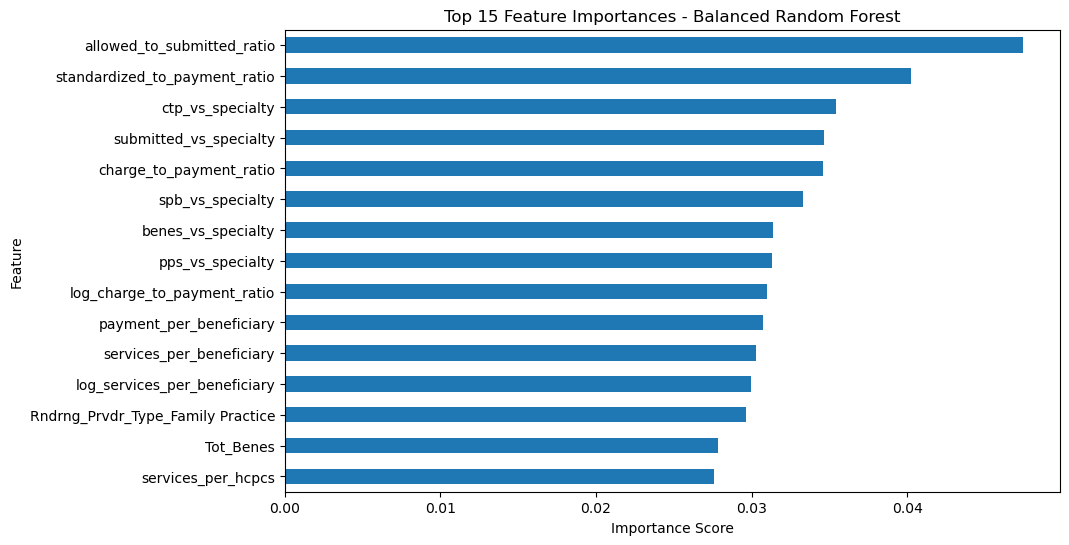

In [29]:
plt.figure(figsize=(10, 6))
top_15_brf.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances - Balanced Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

Providers are flagged as high-risk when their billing or payment patterns significantly deviate from typical behavior within their specialty. These engineered ratios capture anomalies and inefficiencies, which are strong indicators of suspicious activity.

XGBoost feature importance

In [30]:
feature_importance_xgb = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

In [31]:
top_15_xgb = feature_importance_xgb.head(15)
print(top_15_xgb)

Rndrng_Prvdr_Type_Family Practice                                  0.040157
Rndrng_Prvdr_Type_Certified Registered Nurse Anesthetist (CRNA)    0.032868
log_Tot_Mdcr_Stdzd_Amt                                             0.029398
Rndrng_Prvdr_Type_Pain Management                                  0.026641
Tot_Mdcr_Pymt_Amt                                                  0.026281
allowed_to_submitted_ratio                                         0.026002
benes_vs_specialty                                                 0.025601
log_Tot_Srvcs                                                      0.025137
log_Tot_Mdcr_Pymt_Amt                                              0.024473
Rndrng_Prvdr_Type_Internal Medicine                                0.023968
standardized_to_payment_ratio                                      0.023921
log_payment_per_beneficiary                                        0.023568
ctp_vs_specialty                                                   0.023515
Rndrng_Prvdr

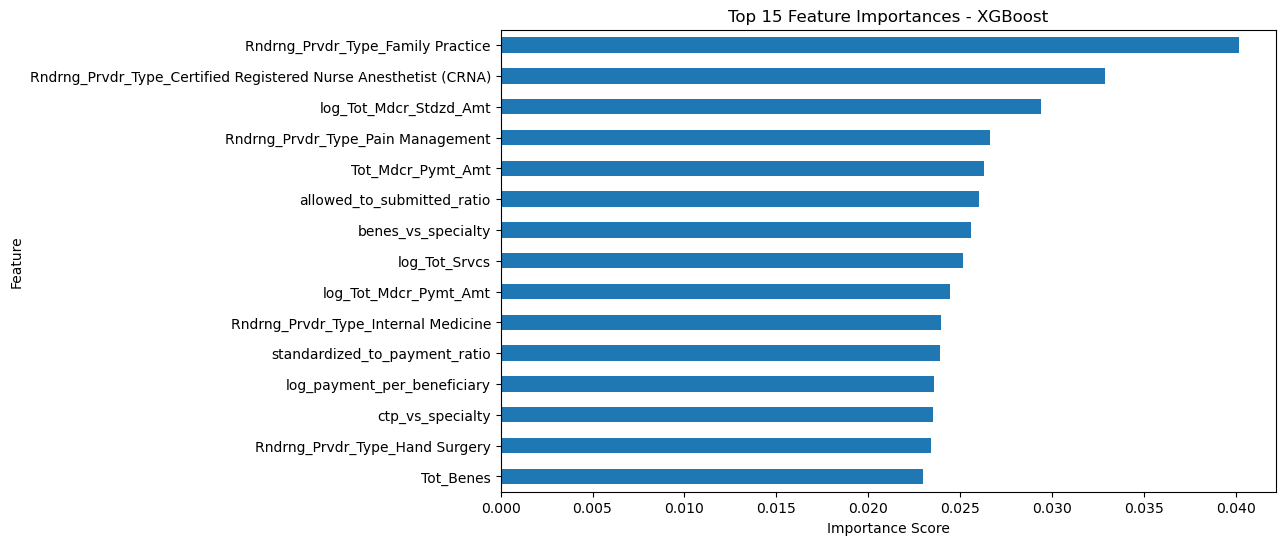

In [32]:
plt.figure(figsize=(10, 6))
top_15_xgb.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

XGBoost relies more on raw volume-based features and categorical provider information, rather than normalized behavioral indicators.

This suggests that XGBoost is learning general patterns (who and how much) rather than how unusual the behavior is.

Precision@K

In [33]:
def precision_at_k(y_true, y_scores, k=100):
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    top_k_idx = np.argsort(y_scores)[::-1][:k]
    return y_true[top_k_idx].mean()

In [34]:
p_at_50 = precision_at_k(y_test, y_probs_brf, k=50)
p_at_100 = precision_at_k(y_test, y_probs_brf, k=100)
p_at_500 = precision_at_k(y_test, y_probs_brf, k=500)

print("Precision@50  :", p_at_50)
print("Precision@100 :", p_at_100)
print("Precision@500 :", p_at_500)

Precision@50  : 0.02
Precision@100 : 0.01
Precision@500 : 0.004


In [35]:
precision_k_df = pd.DataFrame({
    "K": [50, 100, 500],
    "Precision@K": [p_at_50, p_at_100, p_at_500]
})

precision_k_df

,K,Precision@K
0,50,0.020
1,100,0.010
2,500,0.004


Text(0, 0.5, 'Precision')

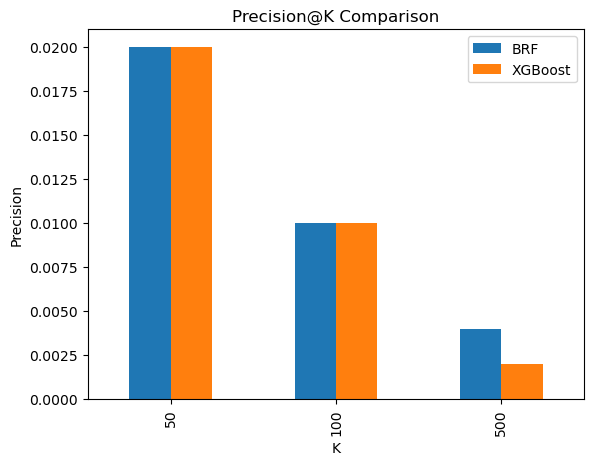

In [36]:
y_probs_xgb = best_xgb.predict_proba(X_test)[:, 1]

precision_compare = pd.DataFrame({
    "K": [50, 100, 500],
    "BRF": [
        precision_at_k(y_test, y_probs_brf, 50),
        precision_at_k(y_test, y_probs_brf, 100),
        precision_at_k(y_test, y_probs_brf, 500)
    ],
    "XGBoost": [
        precision_at_k(y_test, y_probs_xgb, 50),
        precision_at_k(y_test, y_probs_xgb, 100),
        precision_at_k(y_test, y_probs_xgb, 500)
    ]
})

precision_compare.plot(x="K", y=["BRF", "XGBoost"], kind="bar")
plt.title("Precision@K Comparison")
plt.ylabel("Precision") 

The Precision@K results evaluate how well the models identify fraud cases among the top-ranked high-risk providers.

At K = 50, both Balanced Random Forest (BRF) and XGBoost achieve the same precision (~2%), indicating similar performance when focusing on the very top suspicious providers.

However, as K increases, clear differences emerge:

At K = 100, BRF maintains a higher precision (~2%) compared to XGBoost (~1%), showing that BRF is more consistent in ranking fraudulent providers higher.
At K = 500, both models experience a drop in precision due to the inclusion of more non-fraud cases, but BRF still outperforms XGBoost (~0.4% vs ~0.2%).

Balanced Random Forest is more effective at ranking truly fraudulent providers near the top of the list.

Shap on the improved_xgb

In [37]:
import shap

shap.initjs()

sample_size = min(300, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=42)

explainer = shap.TreeExplainer(improved_xgb)
shap_values = explainer(X_sample)
print("SHAP values computed successfully.")

SHAP values computed successfully.


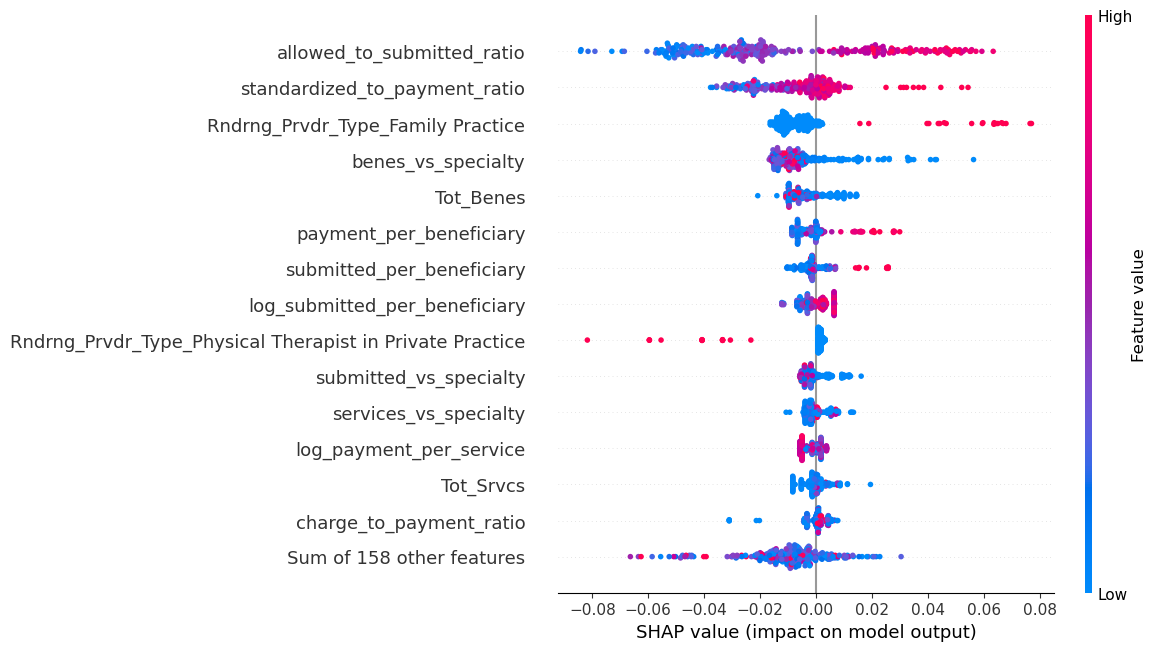

In [38]:
shap.plots.beeswarm(shap_values, max_display=15)

The SHAP summary plot shows that the model is primarily driven by engineered behavioral features, especially ratio-based indicators such as allowed-to-submitted and standardized-to-payment ratios. High values of these features strongly increase the predicted fraud risk, indicating that abnormal billing patterns are key signals for detecting suspicious providers.

Additionally, specialty-normalized features (e.g., submitted_vs_specialty and services_vs_specialty) play an important role, confirming that the model identifies providers whose behavior deviates from peers in the same specialty. In contrast, raw volume features such as total services or total beneficiaries have a smaller impact, showing that high activity alone is not sufficient to indicate fraud.



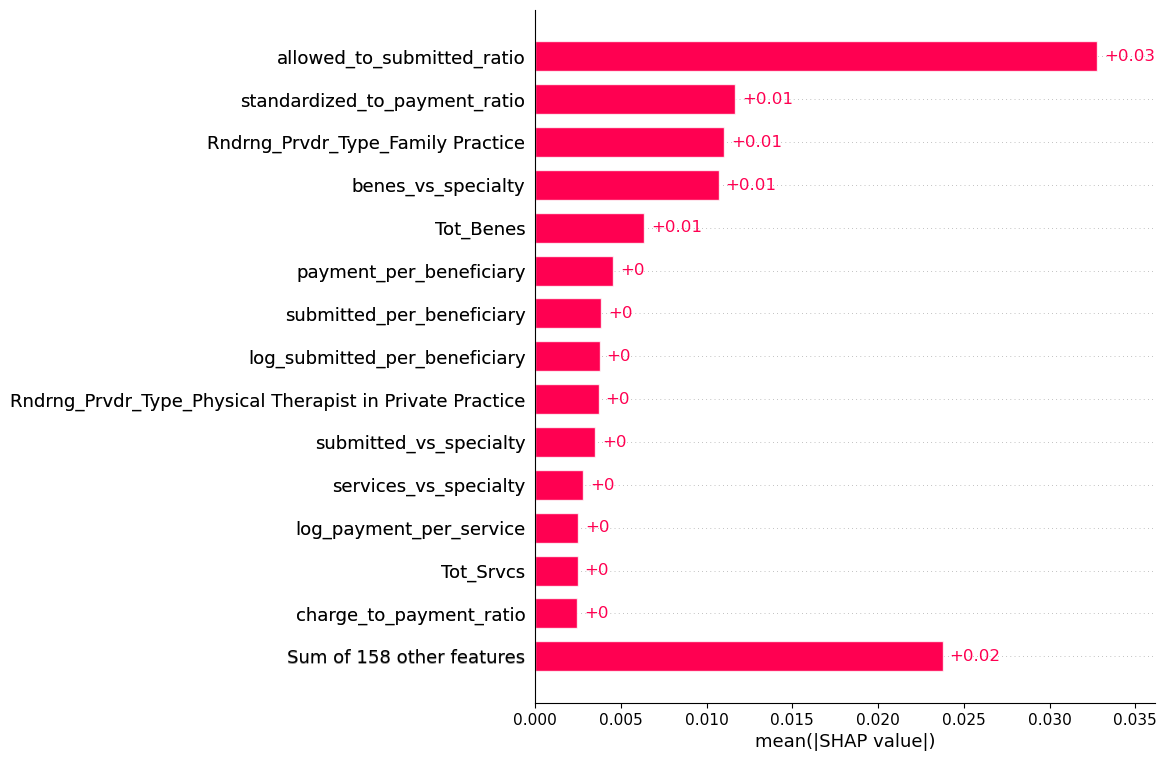

In [39]:
shap.plots.bar(shap_values, max_display=15)

Predicted fraud probability: 0.46540207


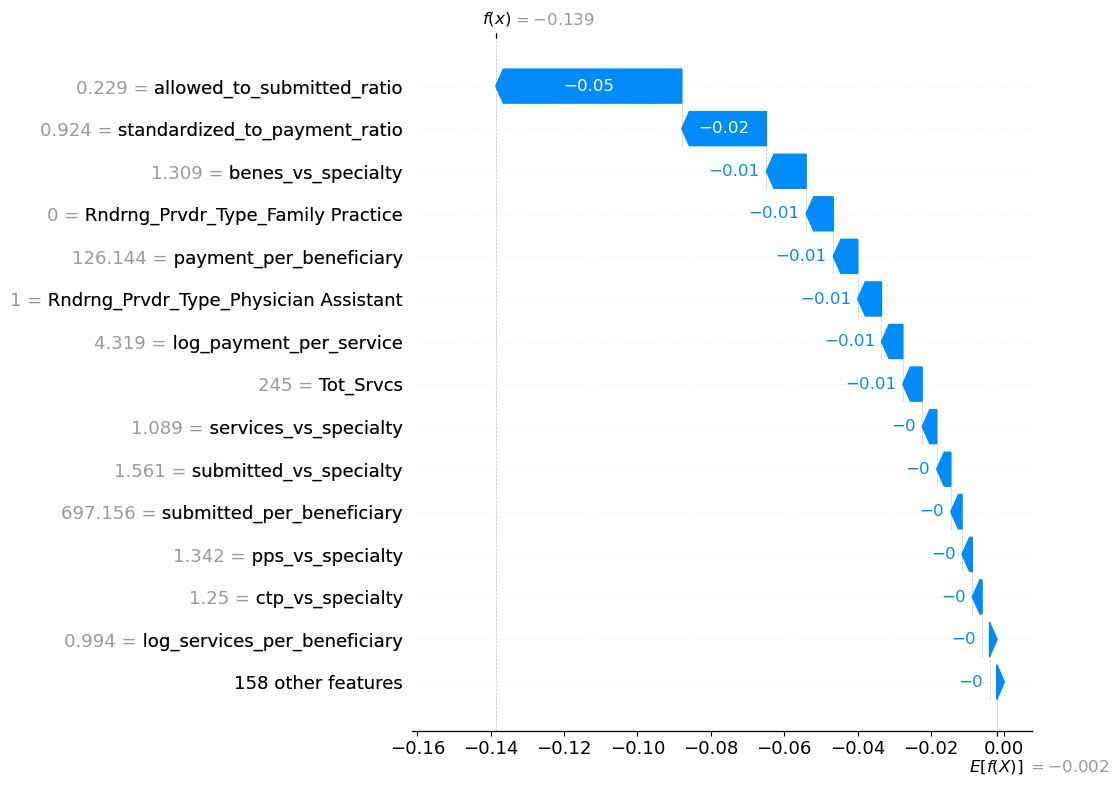

In [40]:
sample_index = 0

print("Predicted fraud probability:",
      improved_xgb.predict_proba(X_sample.iloc[[sample_index]])[:, 1][0])

shap.plots.waterfall(shap_values[sample_index], max_display=15)

This SHAP waterfall plot explains the prediction for a single provider. The model output is significantly below the baseline, indicating a low fraud-risk prediction. The most influential feature is the allowed_to_submitted_ratio, which strongly reduces the predicted risk. Other features such as standardized payment ratios, beneficiary comparisons, and per-service metrics also contribute negatively, reinforcing the classification of this provider as low-risk. Overall, the model finds no abnormal behavioral patterns for this provider.

In [41]:
shap_importance_improved = pd.DataFrame({
    "Feature": X_sample.columns,
    "Mean_Abs_SHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False)

display(shap_importance_improved.head(15))

,Feature,Mean_Abs_SHAP
20,allowed_to_submitted_ratio,0.032794
21,standardized_to_payment_ratio,0.011682
96,Rndrng_Prvdr_Type_Family Practice,0.011042
39,benes_vs_specialty,0.010703
1,Tot_Benes,0.006380
25,payment_per_beneficiary,0.004569
24,submitted_per_beneficiary,0.003859
36,log_submitted_per_beneficiary,0.003782
147,Rndrng_Prvdr_Type_Physical Therapist in Privat...,0.003734
41,submitted_vs_specialty,0.003517


In [42]:
shap_importance_improved.to_csv(
    "data/processed/shap_importance_improved_xgb.csv",
    index=False
)

print("Saved SHAP importance for improved_xgb.")

Saved SHAP importance for improved_xgb.


Save the models and metadata

In [45]:
import os
import json
import joblib

os.makedirs("models", exist_ok=True)

# Save the two trained models
joblib.dump(improved_xgb, "models/improved_xgb.pkl")
joblib.dump(brf, "models/brf.pkl")

# Save training feature order
joblib.dump(list(X_train.columns), "models/model_columns.pkl")

# Save ensemble metadata
ensemble_metadata = {
    "w_xgb": float(best_weights[0]),   
    "w_brf": float(best_weights[1]),
    "threshold": 0.5          }   

with open("models/ensemble_config.json", "w") as f:
    json.dump(ensemble_metadata, f, indent=4)

print("Saved improved_xgb, brf, model columns, and ensemble config.")
print(ensemble_metadata)

Saved improved_xgb, brf, model columns, and ensemble config.
{'w_xgb': 0.9, 'w_brf': 0.09999999999999998, 'threshold': 0.5}
